In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Titanic.csv")

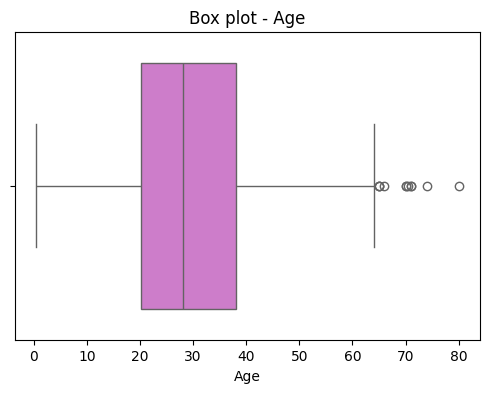

In [3]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'],color='orchid')
plt.title('Box plot - Age')
plt.xlabel('Age')
plt.show()


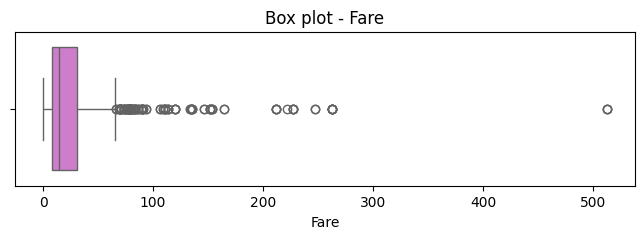

In [4]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Fare'],color='orchid')
plt.title('Box plot - Fare')
plt.xlabel('Fare')
plt.show()


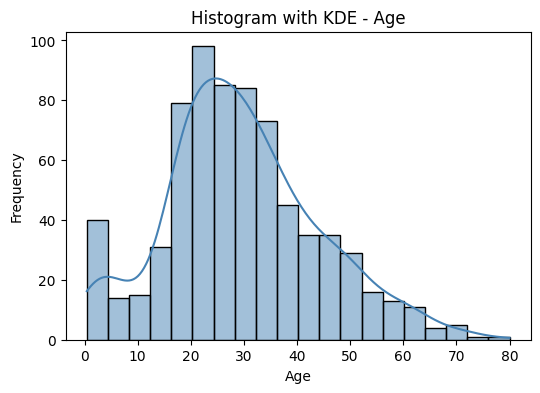

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'],kde=True,color='steelblue')
plt.title('Histogram with KDE - Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

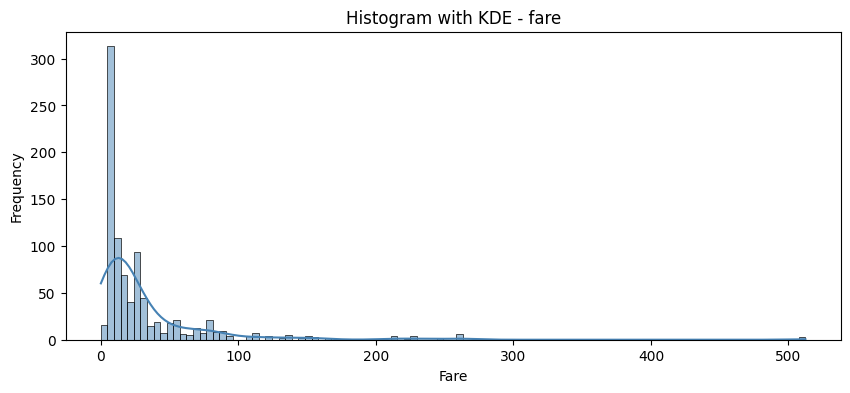

In [6]:
plt.figure(figsize=(10,4))
sns.histplot(df['Fare'],kde=True,color='steelblue')
plt.title('Histogram with KDE - fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

#### How to measure the outliers

In [7]:
IQR=df['Fare'].quantile(0.75)-df['Fare'].quantile(0.25)
IQR

np.float64(23.0896)

In [8]:
#calculating the boundaries
lower_fence=df['Fare'].quantile(0.25)-(IQR*1.5)
upper_fence=df['Fare'].quantile(0.75)+(IQR*1.5)

print("Lower boundary : ",lower_fence)
print("Upper boundary : ",upper_fence)

Lower boundary :  -26.724
Upper boundary :  65.6344


In [9]:
outliers = df[(df['Fare'] > upper_fence) | (df['Fare'] < lower_fence)]
print("Outliers in Fare column:")
print(outliers['Fare'])
print("Number of outliers in Fare column:", len(outliers))

Outliers in Fare column:
1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64
Number of outliers in Fare column: 116


In [10]:
#calculating the boundaries
lower_fence=df['Fare'].quantile(0.25)-(IQR*3)
upper_fence=df['Fare'].quantile(0.75)+(IQR*3)

print("Lower boundary : ",lower_fence)
print("Upper boundary : ",upper_fence)

Lower boundary :  -61.358399999999996
Upper boundary :  100.2688


In [11]:
outliers = df[(df['Fare'] > upper_fence) | (df['Fare'] < lower_fence)]

print("Outliers in Fare column:")
print(outliers['Fare'])
print("Number of outliers in Fare column:", len(outliers))

Outliers in Fare column:
27     263.0000
31     146.5208
88     263.0000
118    247.5208
195    146.5208
215    113.2750
258    512.3292
268    153.4625
269    135.6333
297    151.5500
299    247.5208
305    151.5500
306    110.8833
307    108.9000
311    262.3750
318    164.8667
319    134.5000
325    135.6333
332    153.4625
334    133.6500
337    134.5000
341    263.0000
373    135.6333
377    211.5000
380    227.5250
390    120.0000
393    113.2750
435    120.0000
438    263.0000
498    151.5500
505    108.9000
527    221.7792
537    106.4250
544    106.4250
550    110.8833
557    227.5250
581    110.8833
609    153.4625
659    113.2750
660    133.6500
679    512.3292
689    211.3375
698    110.8833
700    227.5250
708    151.5500
716    227.5250
730    211.3375
737    512.3292
742    262.3750
763    120.0000
779    211.3375
802    120.0000
856    164.8667
Name: Fare, dtype: float64
Number of outliers in Fare column: 53


#### Handling outliers

In [12]:
from scipy.stats import zscore

#drop missing Fare values
df=df[['Fare']].dropna()

#calculate z-scores
df['z_score']=zscore(df['Fare'])

#identify outliers using z-score threshold
df_filtered=df[(df['z_score']>=-3) & (df['z_score']<=3)]

df_filtered

,Fare,z_score
0,7.2500,-0.502445
1,71.2833,0.786845
2,7.9250,-0.488854
3,53.1000,0.420730
4,8.0500,-0.486337
...,...,...
886,13.0000,-0.386671
887,30.0000,-0.044381
888,23.4500,-0.176263
889,30.0000,-0.044381


#### Z-score method

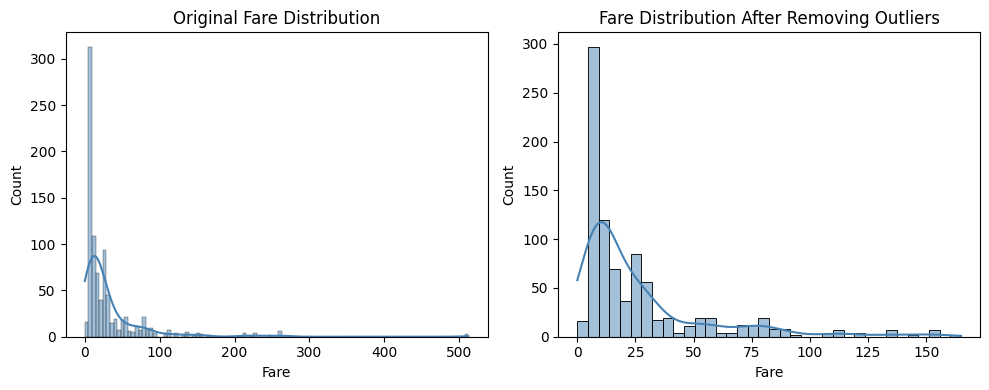

In [13]:
#plotting the z-score outliers
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Fare'],kde=True,color='steelblue')
plt.title('Original Fare Distribution')

#After removing outliers
plt.subplot(1,2,2)
sns.histplot(df_filtered['Fare'],kde=True,color='steelblue')
plt.title('Fare Distribution After Removing Outliers')

plt.tight_layout()
plt.show()

In [14]:
#calculate Q1, Q3 and IQR
Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)
IQR=Q3-Q1
#calculate lower and upper bounds
lower_bound=Q1-(3*IQR)
upper_bound=Q3+(3*IQR)

df_iqr_filtered=df[(df['Fare']>=lower_bound) & (df['Fare']<=upper_bound)]

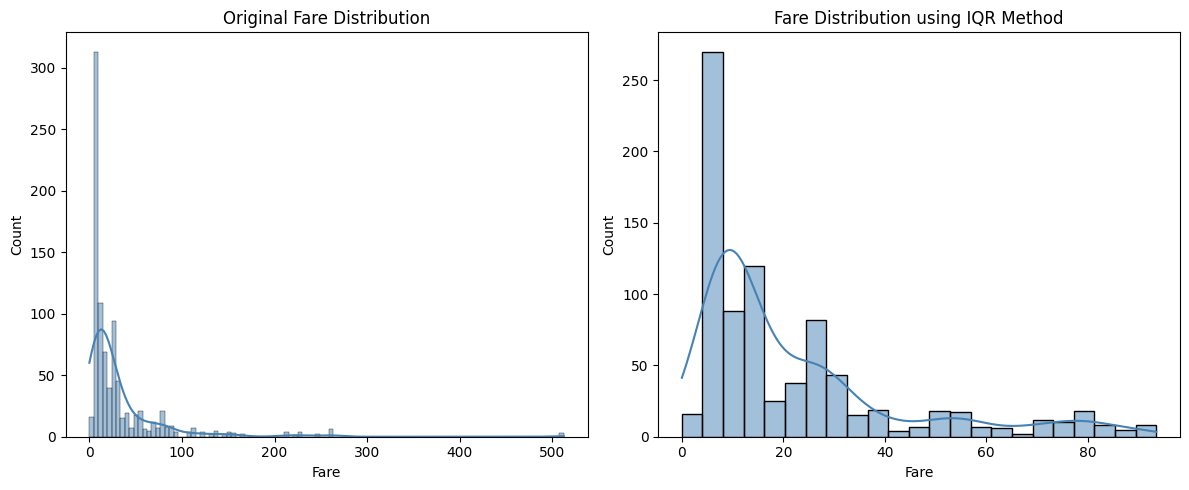

In [15]:
#plotting the z-score outliers
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Fare'],kde=True,color='steelblue')
plt.title('Original Fare Distribution')

#After removing outliers
plt.subplot(1,2,2)
sns.histplot(df_iqr_filtered['Fare'],kde=True,color='steelblue')
plt.title('Fare Distribution using IQR Method')

plt.tight_layout()
plt.show()

## Standarization

In [16]:
from sklearn.preprocessing import StandardScaler

#initialize standard scaler
scaler=StandardScaler()
#fit and transform the age column
df=pd.read_csv("Titanic.csv")
age_clean=df['Age'].dropna()

# Or age_clean = df[['Age']].dropna() which no require to convert to dataframe as it is already a dataframe

#as age_clean is a series data structure
age_clean = age_clean.to_frame()
scaled_data = scaler.fit_transform(age_clean)

#convert back to dataframe
scaled_data=pd.DataFrame(scaled_data,columns=age_clean.columns)
print(scaled_data.describe())
print(scaled_data.sample(10))

                Age
count  7.140000e+02
mean   2.338621e-16
std    1.000701e+00
min   -2.016979e+00
25%   -6.595416e-01
50%   -1.170488e-01
75%    5.718310e-01
max    3.465126e+00
          Age
382 -1.908136
467  0.365167
422 -0.874817
508 -1.908136
317 -0.530377
661 -1.977024
125  1.467375
177 -0.943705
277  0.434055
265 -0.943705


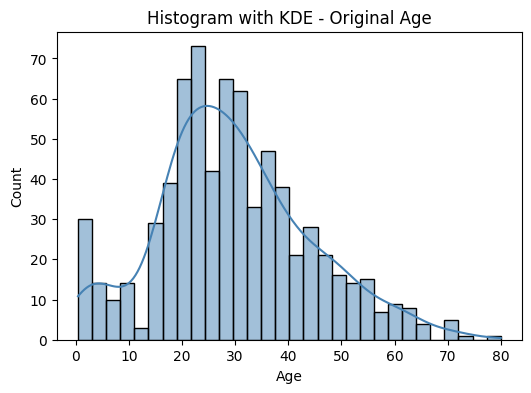

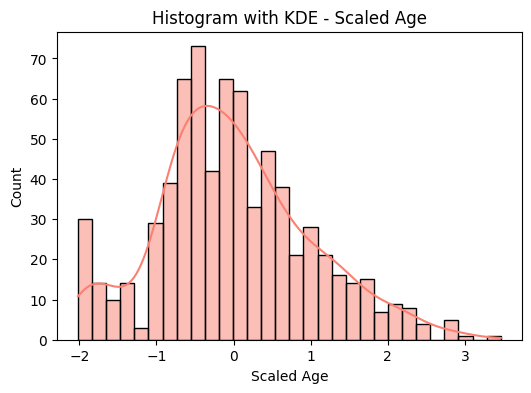

In [17]:

plt.figure(figsize=(6,4))
sns.histplot(age_clean['Age'],kde=True,bins=30, color='steelblue')
plt.title('Histogram with KDE - Original Age')
plt.xlabel('Age')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(scaled_data['Age'],kde=True,color='salmon',bins=30)
plt.title('Histogram with KDE - Scaled Age')
plt.xlabel('Scaled Age')
plt.show()

In [18]:
num_data=df.select_dtypes(include=[np.number])

In [19]:
print("Numerical columns in the dataset:", num_data.columns.tolist())

Numerical columns in the dataset: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [20]:
clean_fare=num_data['Fare'].dropna()
scaled_fare=scaler.fit_transform(clean_fare.values.reshape(-1,1))
scaled_fare=pd.DataFrame(scaled_fare,columns=['Fare'])
print(scaled_fare.describe())
print(scaled_fare.sample(10))

               Fare
count  8.910000e+02
mean   3.987333e-18
std    1.000562e+00
min   -6.484217e-01
25%   -4.891482e-01
50%   -3.573909e-01
75%   -2.424635e-02
max    9.667167e+00
         Fare
781  0.499256
256  0.946246
237 -0.119886
795 -0.386671
1    0.786845
409 -0.135658
846  0.751946
698  1.584179
132 -0.356469
379 -0.491874


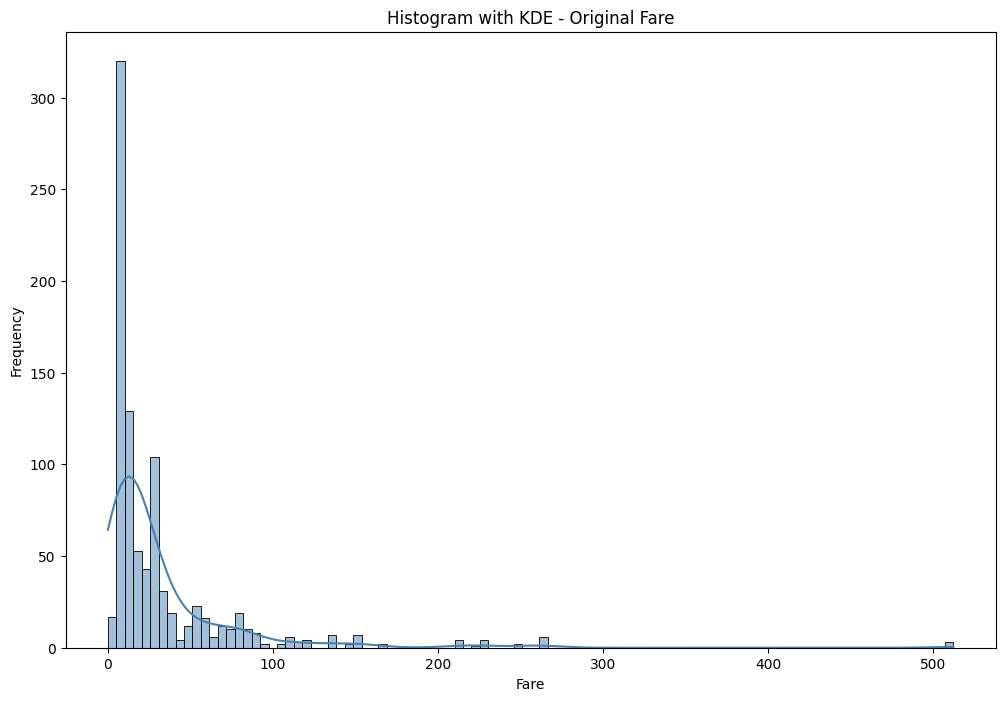

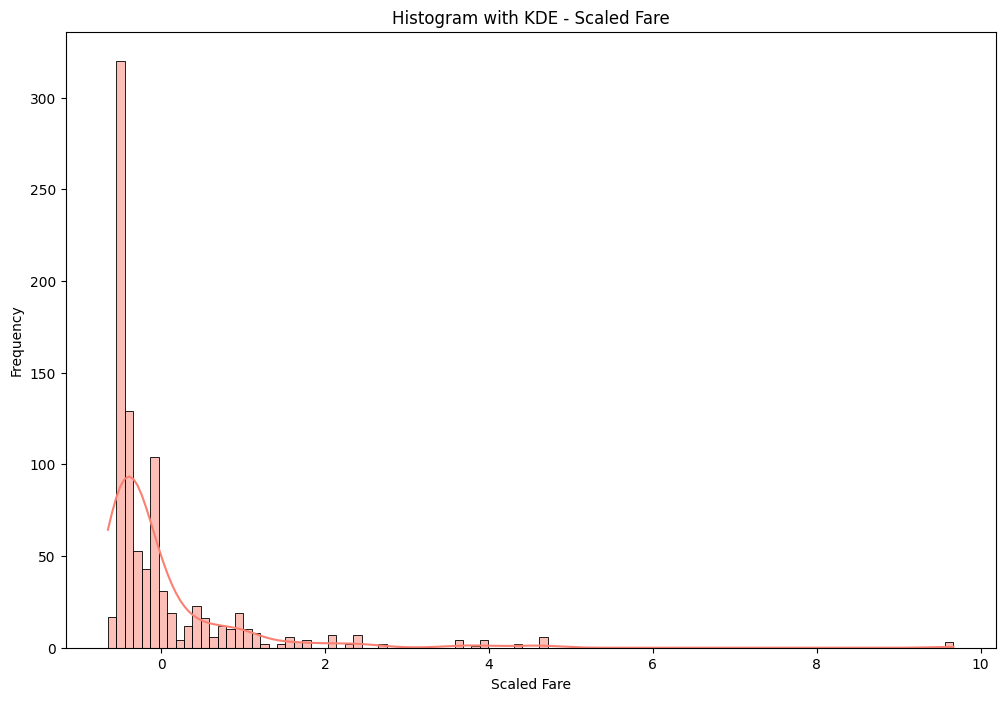

In [21]:
plt.figure(figsize=(12,8))
sns.histplot(clean_fare,kde=True,color='steelblue',bins=100)
plt.title('Histogram with KDE - Original Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(12,8))
sns.histplot(scaled_fare['Fare'],kde=True,color='salmon',bins=100)
plt.title('Histogram with KDE - Scaled Fare')
plt.xlabel('Scaled Fare')
plt.ylabel('Frequency')
plt.show()

## Normalization

In [22]:
from sklearn.preprocessing import MinMaxScaler

#apply min-max scaling to the Fare column
scaler=MinMaxScaler()
normalized_data=scaler.fit_transform(age_clean)

#convert back to dataframe
normalized_data=pd.DataFrame(normalized_data,columns=age_clean.columns)
print(normalized_data.describe())
print(normalized_data.sample(10))


              Age
count  714.000000
mean     0.367921
std      0.182540
min      0.000000
25%      0.247612
50%      0.346569
75%      0.472229
max      1.000000
          Age
411  0.421965
637  0.421965
151  0.396833
105  0.359135
421  0.019854
121  0.635587
149  0.497361
257  0.271174
212  0.497361
202  0.359135


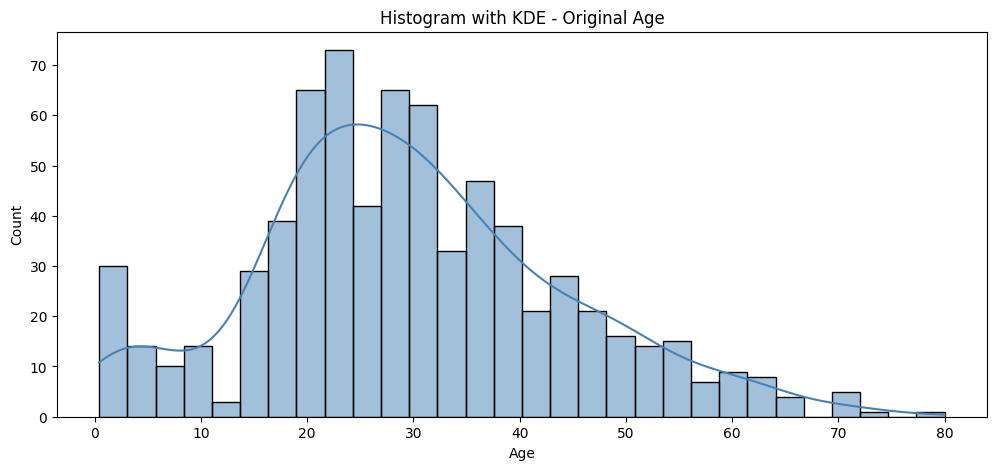

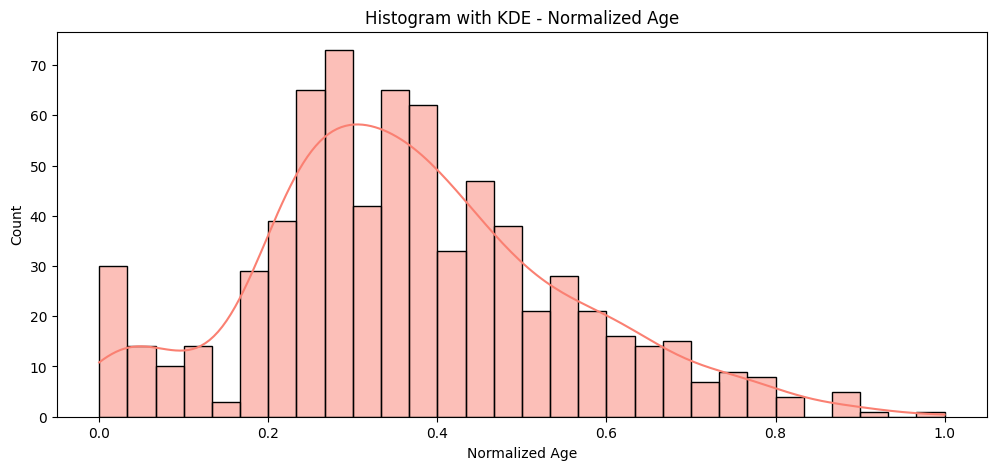

In [23]:
plt.figure(figsize=(12,5))
sns.histplot(age_clean['Age'],kde=True,color='steelblue',bins=30)
plt.title('Histogram with KDE - Original Age')
plt.xlabel('Age')
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(normalized_data['Age'],kde=True,color='salmon',bins=30)
plt.title('Histogram with KDE - Normalized Age')
plt.xlabel('Normalized Age')
plt.show()

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
normalized_fare=scaler.fit_transform(clean_fare.to_frame())
normalized_fare=pd.DataFrame(normalized_fare,columns=['Fare'])
print(normalized_fare.describe())
print(normalized_fare.sample(10))


             Fare
count  891.000000
mean     0.062858
std      0.096995
min      0.000000
25%      0.015440
50%      0.028213
75%      0.060508
max      1.000000
         Fare
883  0.020495
225  0.018250
503  0.018714
710  0.096626
179  0.000000
535  0.051237
866  0.027050
197  0.016404
786  0.014631
120  0.143462


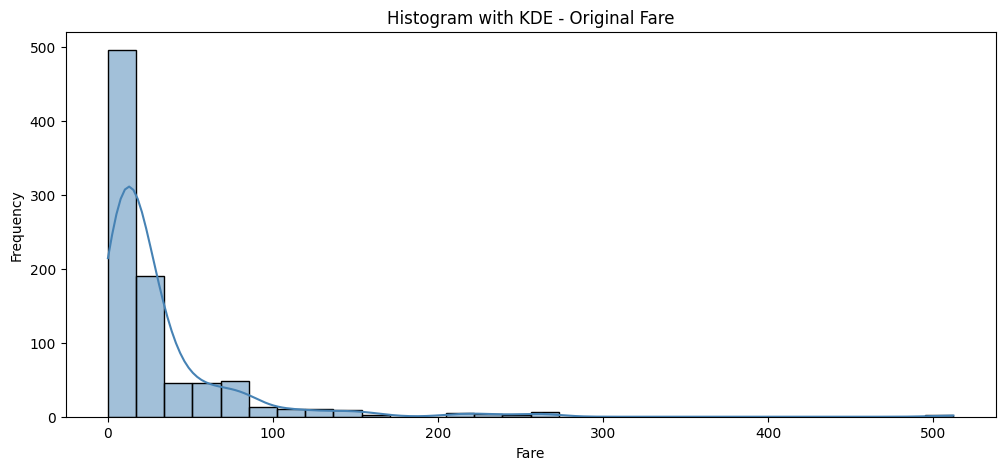

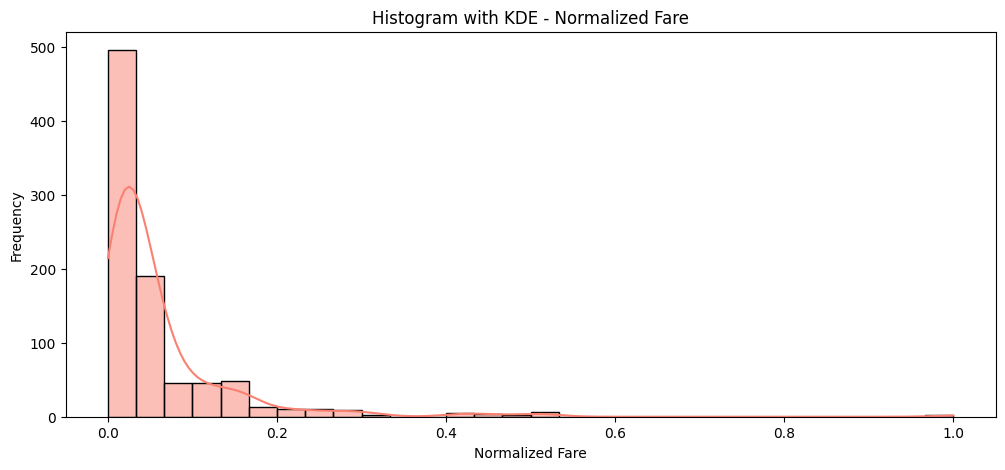

In [25]:
plt.figure(figsize=(12,5))
sns.histplot(clean_fare,kde=True,color='steelblue',bins=30)
plt.title('Histogram with KDE - Original Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(normalized_fare['Fare'],kde=True,color='salmon',bins=30)
plt.title('Histogram with KDE - Normalized Fare')
plt.xlabel('Normalized Fare')
plt.ylabel('Frequency')
plt.show()

| Feature               | Standardization              | Normalization                  |
| --------------------- | ---------------------------- | ------------------------------ |
| Purpose               | Centers data around mean     | Scales data to a fixed range   |
| Formula               | `(x − mean) / std`           | `(x − min) / (xmax − xmin)`    |
| Output range          | No fixed range               | Usually `0 → 1`                |
| Mean after scaling    | ≈ `0`                        | Not fixed                      |
| Standard deviation    | ≈ `1`                        | Not fixed                      |
| Effect of outliers    | Less affected                | More affected                  |
| Shape of distribution | Preserves distribution shape | Compresses values into a range |
| Scikit-learn class    | `StandardScaler()`           | `MinMaxScaler()`               |
| Common use            | Regression, SVM, PCA         | Neural Networks, KNN           |


## Binarization

In [28]:
from sklearn.preprocessing import Binarizer

df_age=df[['Age']].dropna().copy()

#binarize age 1 if age is greater than 18 else 0
binarizer=Binarizer(threshold=18)
binarized_age=binarizer.fit_transform(df_age)

#add binary column to the dataframe
df_age['Age_Binary']=binarized_age

df_age.sample(10)

,Age,Age_Binary
477,29.0,1.0
436,21.0,1.0
58,5.0,0.0
136,19.0,1.0
446,13.0,0.0
623,21.0,1.0
406,51.0,1.0
772,57.0,1.0
309,30.0,1.0
733,23.0,1.0


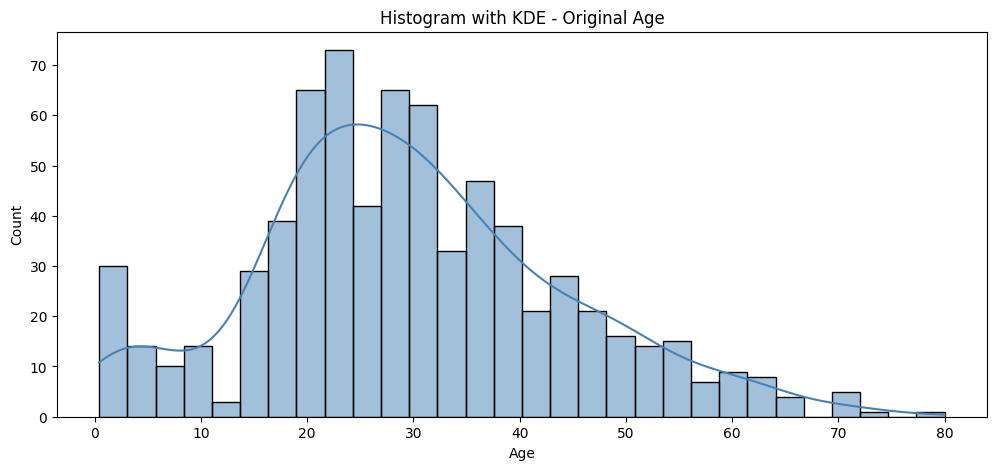

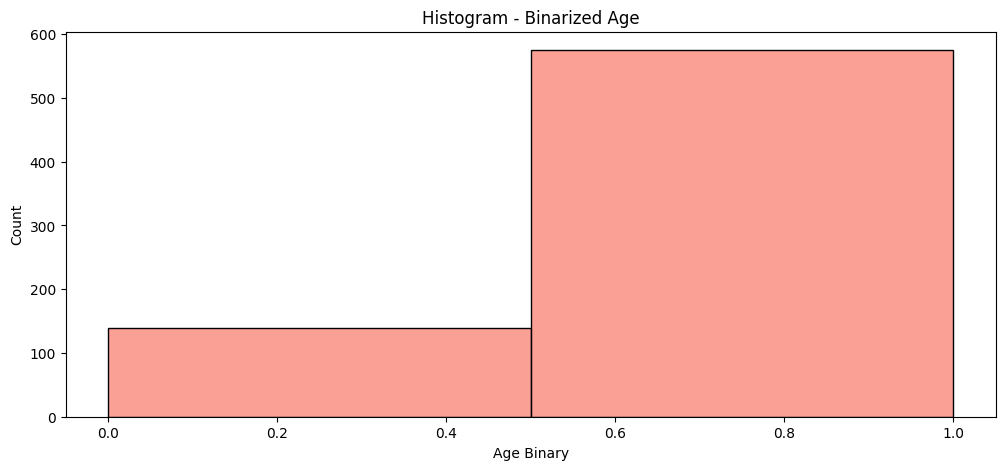

In [29]:
plt.figure(figsize=(12,5))
sns.histplot(df['Age'],kde=True,color='steelblue',bins=30)
plt.title('Histogram with KDE - Original Age')
plt.xlabel('Age')
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df_age['Age_Binary'],kde=False,color='salmon',bins=2)
plt.title('Histogram - Binarized Age')
plt.xlabel('Age Binary')
plt.show()

## Robust Scaling

In [30]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
scaled_data= scaler.fit_transform(age_clean)
scaled_data=pd.DataFrame(scaled_data,columns=age_clean.columns)
print(scaled_data.describe())
print(scaled_data.sample(10))

              Age
count  714.000000
mean     0.095056
std      0.812671
min     -1.542937
25%     -0.440559
50%      0.000000
75%      0.559441
max      2.909091
          Age
515 -0.391608
676  0.391608
348 -0.783217
695 -0.111888
92   0.055944
122 -0.335664
11  -0.447552
266  0.979021
373  1.566434
660 -1.454545


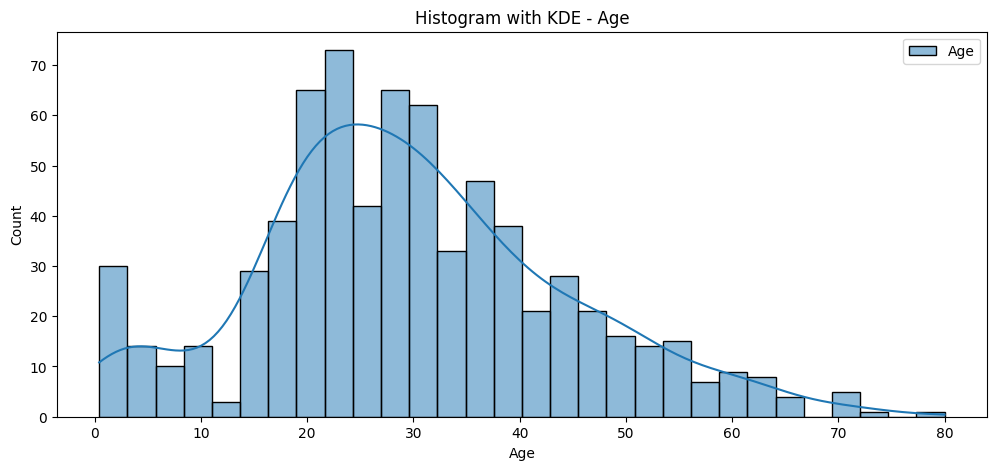

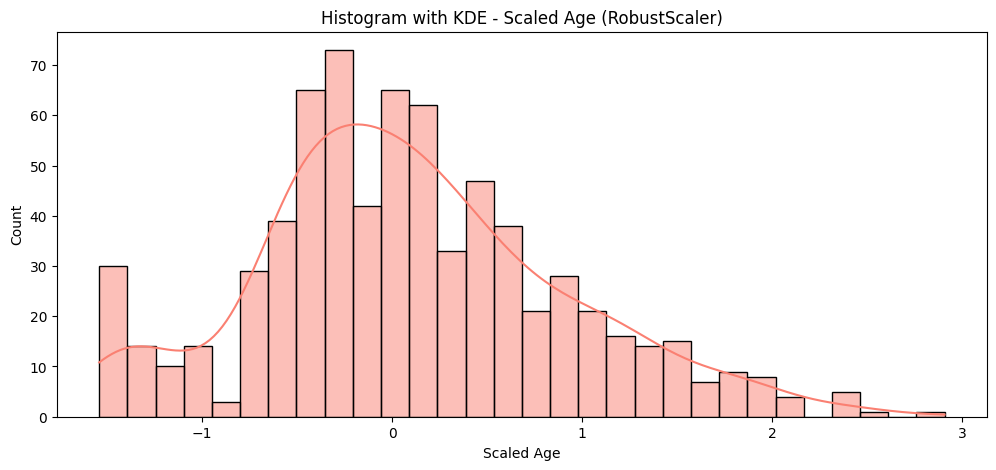

In [31]:
plt.figure(figsize=(12,5))
sns.histplot(age_clean,kde=True,color='steelblue',bins=30)
plt.title('Histogram with KDE - Age')
plt.xlabel('Age')
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(scaled_data['Age'],kde=True,color='salmon',bins=30)
plt.title('Histogram with KDE - Scaled Age (RobustScaler)')
plt.xlabel('Scaled Age')
plt.show()

| Scaling Type    | Uses        | Sensitive to Outliers |
| --------------- | ----------- | --------------------- |
| Normalization   | Min, Max    | Yes                   |
| Standardization | Mean, Std   | Moderate              |
| Robust Scaling  | Median, IQR | No                    |


| Feature            | Standardization          | Normalization                  | Robust Scaling                            | Binarization                |
| ------------------ | ------------------------ | ------------------------------ | ----------------------------------------- | --------------------------- |
| Purpose            | Centers data around mean | Scales values to a fixed range | Scales data while reducing outlier impact | Converts values into 0 or 1 |
| Formula            | `(x − mean) / std`       | `(x − min) / (xmax − xmin)`    | `(x − median) / (Q3 − Q1)`                | `x > threshold → 1, else 0` |
| Uses               | Mean, Standard Deviation | Min, Max                       | Median, IQR                               | Threshold                   |
| Output Range       | No fixed range           | Usually `0 → 1`                | No fixed range                            | `0` or `1`                  |
| Effect of Outliers | Less affected            | Highly affected                | Least affected                            | Depends on threshold        |
| Best For           | Regression, SVM, PCA     | Neural Networks, KNN           | Data with outliers                        | Binary feature creation     |
| Scikit-learn Class | `StandardScaler()`       | `MinMaxScaler()`               | `RobustScaler()`                          | `Binarizer()`               |
